In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import ssl

# 临时解决网络下载问题（避免HTTPError）
ssl._create_default_https_context = ssl._create_unverified_context

# 加载数据集
housing = fetch_california_housing()

# 转成DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # 房价标签

print(df.head())
print("特征列表：", housing.feature_names)
print("数据集形状：", df.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
特征列表： ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据集形状： (20640, 9)


In [3]:
def normalize(X):#均值归一法
    """把所有特征缩放到 [0, 1] 之间"""""
    X_min = X.min(axis = 0)
    X_max = X.max(axis = 0)
    return (X-X.mean(axis = 0))/(X_max-X_min)
def standardize(X):#标准化
    """把数据变成均值0、标准差1的分布"""
    mu = X.mean(axis=0)     # 每列的均值
    sigma = X.std(axis=0)   # 每列的标准差
    return (X - mu) / sigma

In [4]:
X = df[housing.feature_names].values
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [8]:
#均值归一化
X_norm = normalize(X)
#标准化
X_std = standardize(X)
X_norm,X_std

(array([[ 0.30720466,  0.24236301,  0.01102435, ...,  0.23890952,
         -0.26496968,  0.50668695],
        [ 0.3055633 , -0.14979385,  0.005736  , ...,  0.23678412,
         -0.26397366,  0.31266713],
        [ 0.2335643 ,  0.45804929,  0.02026851, ...,  0.23572142,
         -0.26596569,  0.29947131],
        ...,
        [-0.14969938, -0.22822522, -0.00158409, ...,  0.4036279 ,
         -0.16437207, -0.23619659],
        [-0.13816851, -0.20861738, -0.00070527, ...,  0.4036279 ,
         -0.17433223, -0.25186663],
        [-0.10221038, -0.24783307, -0.0012355 , ...,  0.39725171,
         -0.1663641 , -0.24217594]]),
 array([[ 2.34476576,  0.98214266,  0.62855945, ...,  1.05254828,
         -1.32783522,  2.12963148],
        [ 2.33223796, -0.60701891,  0.32704136, ...,  1.04318455,
         -1.32284391,  1.31415614],
        [ 1.7826994 ,  1.85618152,  1.15562047, ...,  1.03850269,
         -1.33282653,  1.25869341],
        ...,
        [-1.14259331, -0.92485123, -0.09031802, ...,  

# 1. 创建模型实例
model = LinearRegression()

# 2. 用训练数据“拟合”模型
model.fit(X_train, y_train)

# 3. 用测试数据“预测”
y_pred = model.predict(X_test)


拆分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)
test_size 测试集比例 
随机种子：设置 random_state 可以确保每次运行得到相同的划分结果

             训练时间         MSE       
原始数据         0.006999     0.5559    
标准化后         0.011505     0.5389    


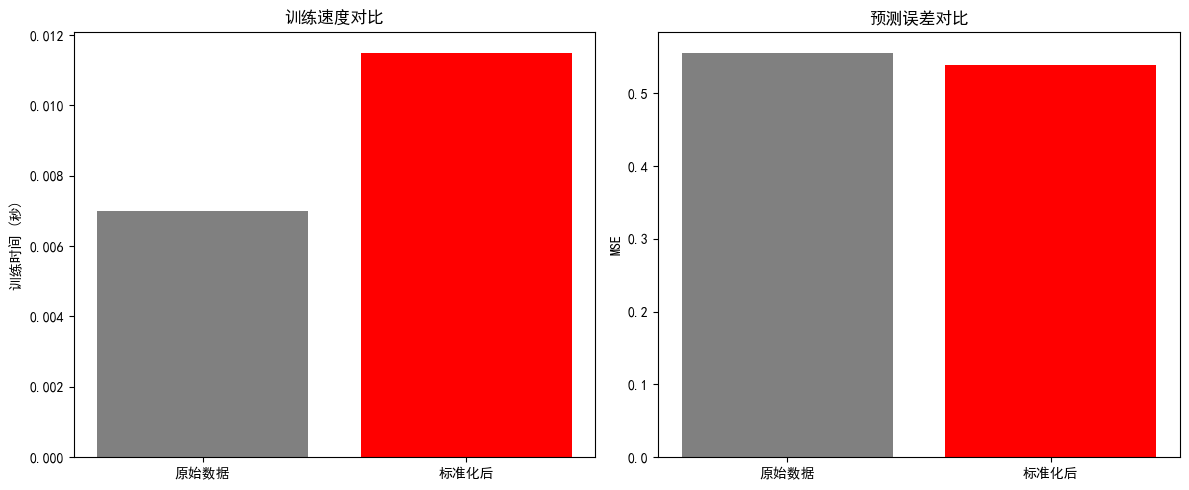

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 设置中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ========== 准备数据 ==========
X = df[housing.feature_names].values
y = df['MedHouseVal'].values

# 拆分训练/测试集
X_train, X_test, y_train, y_test = (X, y, test_size=0.2, random_state=42)

# ========== 实验1：用原始数据训练 ==========
model_raw = LinearRegression() #创建模型实例
start = time.time()#当前时间
model_raw.fit(X_train, y_train)#训练数据拟合模型
end = time.time()
time_raw = end - start
mse_raw = np.mean((model_raw.predict(X_test) - y_test) ** 2)

# ========== 实验2：用标准化数据训练 ==========
X_train_std = standardize(X_train)
X_test_std = standardize(X_test)

model_std = LinearRegression()
start = time.time()
model_std.fit(X_train_std, y_train)
end = time.time()
time_std = end - start
mse_std = np.mean((model_std.predict(X_test_std) - y_test) ** 2)

# ========== 输出对比结果 ==========
print("=" * 40)
print(f"{'':<12} {'训练时间':<12} {'MSE':<10}")
print(f"{'原始数据':<12} {time_raw:<12.6f} {mse_raw:<10.4f}")
print(f"{'标准化后':<12} {time_std:<12.6f} {mse_std:<10.4f}")
print("=" * 40)

# ========== 画图对比 ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) #一行二列子图 fig-整个画布对象 axes-长度

# 左：时间对比
axes[0].bar(['原始数据', '标准化后'], [time_raw, time_std], color=['gray', 'red'])
axes[0].set_ylabel('训练时间 (秒)')
axes[0].set_title('训练速度对比')

# 右：MSE对比
axes[1].bar(['原始数据', '标准化后'], [mse_raw, mse_std], color=['gray', 'red'])
axes[1].set_ylabel('MSE')
axes[1].set_title('预测误差对比')

plt.tight_layout()#自动调整子图间距
plt.show()